In [139]:
import sys
sys.path.append("../../src")

from common_imports import *
from collections import Counter

In [ ]:
#####
# Construct D tilde# 

def pos_z(g, z):
    return 1.0 - g*z

def neg_z(g, z):
    return 1.0 - g/z

def D_tilde(g, z, T):
    pz = pos_z(g, z)
    nz = neg_z(g, z)
    # use a single sqrt for the product to reduce branch inconsistencies
    arg = sqrt(pz*nz) / T
    return sqrt(pz/nz) * tanh(arg)


def D(N, g, T, n):
    # stable TFIM symbol, no branch cuts
    dk = 2*pi / N
    k  = dk * np.arange(N)

    eps = sqrt(1 + g**2 - 2*g*cos(k))        # ε_k ≥ 0
    Dt  = (1 - g*exp(1j*k)) / eps * tanh(eps / T)

    pf = exp(-1j*n*k) / (2*pi)
    return np.sum(pf * Dt) * dk

N = 512
n = 0
import equilibrium_critical_correlations as ecc 
import kblock_ising_model as kb
k = kb.k_vals(1000)


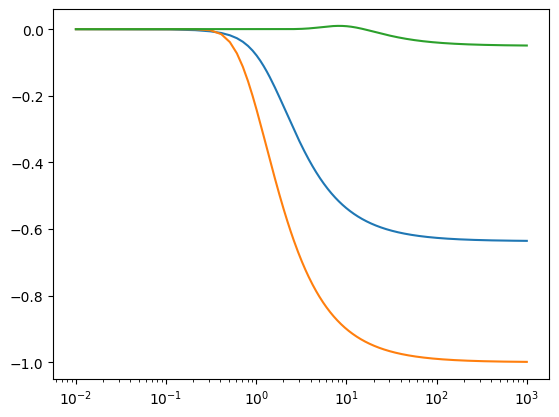

In [113]:
g= 1.00001
T = np.linspace(0.01,1000,10000)
U = kb.U(k,g)
x=kb.sigma_general([0,1],U,k)
dat = array([D(N,g,Ti,n) for Ti in T])-x
plot(T,dat)
g= 0
T = np.linspace(0.01,1000,10000)
U = kb.U(k,g)
x=kb.sigma_general([0,1],U,k)
dat = array([D(N,g,Ti,n) for Ti in T])-x
plot(T,dat)
g= 10
T = np.linspace(0.01,1000,10000)
U = kb.U(k,g)
x=kb.sigma_general([0,1],U,k)
dat = array([D(N,g,Ti,n) for Ti in T])-x
plot(T,dat)
xscale("log")

In [88]:
import equilibrium_critical_correlations as ecc 
import kblock_ising_model as kb
k = kb.k_vals(1000)
U = kb.U(k,10)
kb.sigma_general([0,1],U,k)

np.float64(0.05006273560323078)

In [116]:
#Creating the sigma_general code
def sigma_general(indices,L,g,T):
    
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(L,g,T,Nd)
    return np.linalg.det(C)

Text(0.5, 1.0, 'g=1e-05')

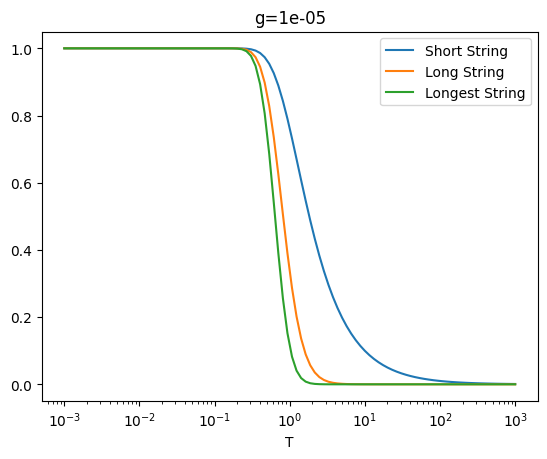

In [136]:
np.real(sigma_general([0,1],512,1.01,0.01))

g= 0.00001
T = np.logspace(-3,3,100)
dat = array([sigma_general([0,1],N,g,Ti) for Ti in T])
plot(T,dat/np.max(dat),label="Short String ")
dat = array([sigma_general([0,1,2,3,4,5,6,7],N,g,Ti) for Ti in T])
plot(T,dat/np.max(dat),label="Long String")
dat = array([sigma_general([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],N,g,Ti) for Ti in T])
plot(T,dat/np.max(dat),label="Longest String")
xscale("log")
legend()
xlabel("T")
title(f"g={g}")

In [137]:

#Typical Pn function
def P_n(n,L,g,T):
    even = True
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,L,g,T)))*degen)
        else:
            dat.append(sigma_general(indices,L,g,T)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'g=0.0')

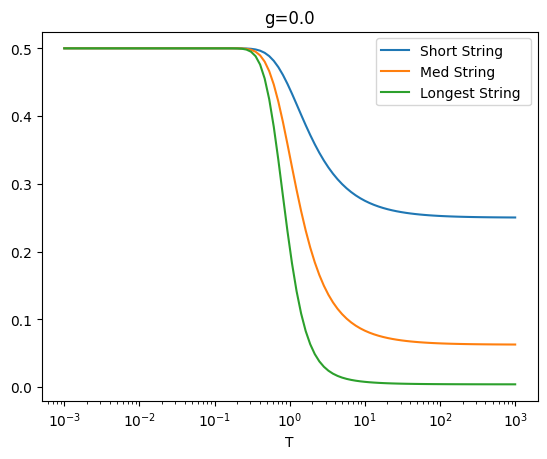

In [149]:
P_n(2,100,0.01,0.01)


g= 0.0000
T = np.logspace(-3,3,100)
dat = array([P_n(2,N,g,Ti) for Ti in T])
plot(T,dat,label="Short String ")
dat = array([P_n(4,N,g,Ti) for Ti in T])
plot(T,dat,label="Med String ")

dat = array([P_n(8,N,g,Ti) for Ti in T])
plot(T,dat,label="Longest String ")
xscale("log")
xlabel("T")
legend()
title(f"g={g}")

Text(0.5, 1.0, 'g=1.00001')

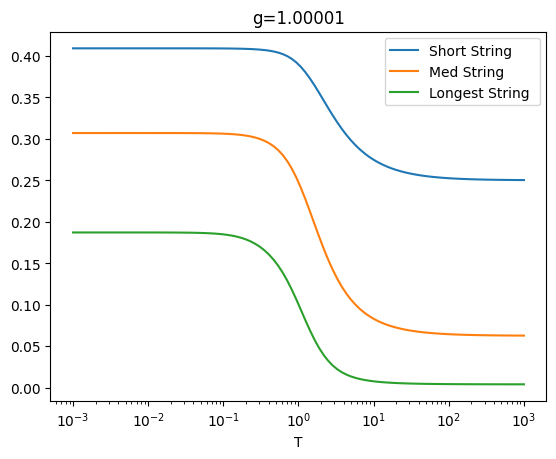

In [150]:
P_n(2,100,0.01,0.01)


g= 1.00001
T = np.logspace(-3,3,100)
dat = array([P_n(2,N,g,Ti) for Ti in T])
plot(T,dat,label="Short String ")
dat = array([P_n(4,N,g,Ti) for Ti in T])
plot(T,dat,label="Med String ")

dat = array([P_n(8,N,g,Ti) for Ti in T])
plot(T,dat,label="Longest String ")
xscale("log")
xlabel("T")
legend()
title(f"g={g}")

/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


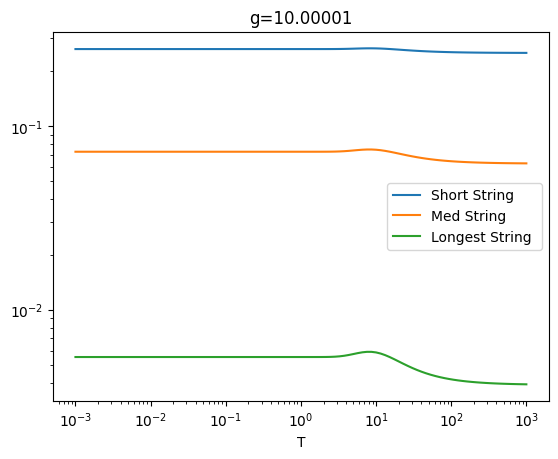

In [152]:
P_n(2,100,0.01,0.01)


g= 10.00001
T = np.logspace(-3,3,100)
dat = array([P_n(2,N,g,Ti) for Ti in T])
plot(T,dat,label="Short String ")
dat = array([P_n(4,N,g,Ti) for Ti in T])
plot(T,dat,label="Med String ")

dat = array([P_n(8,N,g,Ti) for Ti in T])
plot(T,dat,label="Longest String ")
xscale("log")
xlabel("T")
legend()
title(f"g={g}")
yscale("log")

In [154]:
import thermal_equilibrium as therm

therm.sigma_general([0,1],100,1.01,.1)

np.complex128(0.6248367702631374+0j)